[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Jordy-Castillo/FC_Jordy-Castillo-Trabajos/blob/main/Taller03/FC_Taller03_JordyCastillo.ipynb)

# **FISICA COMPUTACIONAL - TALLER #3**
* **Tema:** Ajuste de curvas, regresión lineal y no lineal
* **Lenguaje:** Fortran
* **Estudiante:** Jordy Castillo Jordán
* **Fecha:** 01/10/2026



In [2]:
!which gfortran || (apt-get update -qq && apt-get install -y gfortran)
!gfortran --version | head -n 1

/usr/bin/gfortran
GNU Fortran (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0


# **PARTE A:**




--------------------------------------------------------------------------
1. Abra `100_mediciones_pendulo_minimos_cuadrados.xlsx` y revise la hoja `Datos_estudiantes`.
2. Ejecute el script de limpieza suministrado por el profesor.
3. Complete sus tres tareas: correcciones justificadas, elección del ángulo máximo y exclusiones manuales.
4. No excluya un dato únicamente porque se aleja de la tendencia. Toda corrección o exclusión debe apoyarse en la información experimental.
5. El script debe generar `pendulo_limpio.dat` e `informe_limpieza.xlsx`.

In [4]:
"""Limpieza de mediciones de un péndulo y exportación para Fortran.

Por favor complete los tres bloques marcados como TODO.
"""

from pathlib import Path

import pandas as pd


# ============================================================
# 1. LECTURA DEL ARCHIVO
# ============================================================

ARCHIVO_ENTRADA = Path("100_mediciones_pendulo_minimos_cuadrados.xlsx")
HOJA = "Datos_estudiantes"

if not ARCHIVO_ENTRADA.exists():
    raise FileNotFoundError(
        f"No se encontró {ARCHIVO_ENTRADA}. "
        "Guarde el script y el archivo de Excel en la misma carpeta."
    )

datos = pd.read_excel(ARCHIVO_ENTRADA, sheet_name=HOJA)

columnas_requeridas = [
    "medicion_id",
    "longitud_cm",
    "angulo_inicial_deg",
    "numero_oscilaciones",
    "tiempo_medido_s",
    "observador",
    "observacion_campo",
    "calidad_video",
]

columnas_ausentes = [
    columna for columna in columnas_requeridas if columna not in datos.columns
]

if columnas_ausentes:
    raise ValueError(
        "Faltan columnas obligatorias en el archivo: "
        + ", ".join(columnas_ausentes)
    )

# Se conserva una copia independiente de los datos originales.
datos_originales = datos.copy(deep=True)

print("\nNúmero inicial de registros:", len(datos))
print("\nPrimeras mediciones:")
print(datos.head())


# ============================================================
# 2. COLUMNAS PARA DOCUMENTAR LA LIMPIEZA
# ============================================================

datos["incluir"] = True
datos["accion_limpieza"] = "Conservar"
datos["justificacion"] = "Medición aceptada"


def excluir_registros(condicion, justificacion):
    """Excluye únicamente registros que todavía estaban aceptados."""
    nuevos = condicion.fillna(False) & datos["incluir"]
    datos.loc[nuevos, "incluir"] = False
    datos.loc[nuevos, "accion_limpieza"] = "Excluir"
    datos.loc[nuevos, "justificacion"] = justificacion


# ============================================================
# 3. CORRECCIONES JUSTIFICADAS
# ============================================================

# TODO 1:
# Complete los diccionarios con las correcciones que considere
# justificadas. La forma es:
#
# medicion_id: valor_corregido
#
# Si no desea corregir ningún registro, deje el diccionario vacío.

correcciones_longitud = {52:70
    # medicion_id: longitud_correcta
}

correcciones_tiempo = {23:19.060, 81:18.530
    # medicion_id: tiempo_total_correcto
}

for medicion_id, valor in correcciones_longitud.items():
    condicion = datos["medicion_id"] == medicion_id

    if not condicion.any():
        print(f"Advertencia: no existe la medición {medicion_id}.")
        continue

    datos.loc[condicion, "longitud_cm"] = valor
    datos.loc[condicion, "accion_limpieza"] = "Corregir longitud"
    datos.loc[condicion, "justificacion"] = (
        "Error de registro identificado y corregido"
    )

for medicion_id, valor in correcciones_tiempo.items():
    condicion = datos["medicion_id"] == medicion_id

    if not condicion.any():
        print(f"Advertencia: no existe la medición {medicion_id}.")
        continue

    datos.loc[condicion, "tiempo_medido_s"] = valor
    datos.loc[condicion, "accion_limpieza"] = "Corregir tiempo"
    datos.loc[condicion, "justificacion"] = (
        "El valor registrado no correspondía al tiempo total"
    )


# ============================================================
# 4. EXCLUSIONES AUTOMÁTICAS
# ============================================================

excluir_registros(
    datos["tiempo_medido_s"].isna(),
    "No existe un tiempo medido",
)

excluir_registros(
    datos["numero_oscilaciones"].isna()
    | (datos["numero_oscilaciones"] <= 0),
    "Número de oscilaciones ausente o no positivo",
)


# ============================================================
# 5. DOMINIO DE VALIDEZ DEL MODELO
# ============================================================

# TODO 2:
# Escriba el ángulo máximo, en grados, para el cual utilizará
# la aproximación de ángulo pequeño. Sustituya None por un número.

ANGULO_MAXIMO = 10.0  #DEFINIR AUNGLO MAXIMO SEGUN LA TEORIA

if ANGULO_MAXIMO is None:
    raise ValueError(
        "Debe completar TODO 2: asigne un valor numérico a "
        "ANGULO_MAXIMO."
    )

excluir_registros(
    datos["angulo_inicial_deg"].isna()
    | (datos["angulo_inicial_deg"].abs() > ANGULO_MAXIMO),
    "Fuera de la aproximación de ángulo pequeño",
)


# ============================================================
# 6. BÚSQUEDA DE REGISTROS DUPLICADOS
# ============================================================

variables_experimentales = [
    "longitud_cm",
    "angulo_inicial_deg",
    "numero_oscilaciones",
    "tiempo_medido_s",
    "observador",
]

# Solo se buscan duplicados entre registros aún aceptados. Así, un
# registro ya rechazado no provoca la exclusión de una medición válida.
duplicados = pd.Series(False, index=datos.index)
indices_aceptados = datos.index[datos["incluir"]]
duplicados.loc[indices_aceptados] = datos.loc[
    indices_aceptados
].duplicated(subset=variables_experimentales, keep="first")

excluir_registros(
    duplicados,
    "Registro experimental duplicado",
)


# ============================================================
# 7. CÁLCULOS PRELIMINARES E INSPECCIÓN
# ============================================================

# El período se calcula después de aplicar las correcciones.
datos["periodo_preliminar_s"] = (
    datos["tiempo_medido_s"] / datos["numero_oscilaciones"]
)

print("\nLongitudes potencialmente sospechosas:")
print(
    datos.loc[
        (datos["longitud_cm"] < 20) | (datos["longitud_cm"] > 100),
        ["medicion_id", "longitud_cm", "observacion_campo"],
    ]
)

print("\nPeríodos potencialmente sospechosos:")
print(
    datos.loc[
        (datos["periodo_preliminar_s"] < 0.5)
        | (datos["periodo_preliminar_s"] > 3.0),
        [
            "medicion_id",
            "longitud_cm",
            "numero_oscilaciones",
            "tiempo_medido_s",
            "periodo_preliminar_s",
            "observacion_campo",
        ],
    ]
)

print("\nMediciones con calidad de video baja:")
print(
    datos.loc[
        datos["calidad_video"].eq("Baja"),
        ["medicion_id", "calidad_video", "observacion_campo"],
    ]
)


# ============================================================
# 8. EXCLUSIONES QUE REQUIEREN INTERPRETACIÓN
# ============================================================

# TODO 3:
# Agregue las mediciones que deben excluirse por razones
# experimentales que no fueron tratadas automáticamente:
#
# medicion_id: "justificación"

exclusiones_manuales = {
    12: "Archivo de video no disponible, perdida del tiempo medido",
    36: "Pérdida temporal del marcador en el video (calidad baja)",
    45: "Desfase inicial del cronómetro (inició tarde)",
    60: "Registro importado dos veces",
    68: "Celda sin registrar en la libreta de tiempo medido",
    77: "Pérdida temporal del marcador en el video (calidad baja)",
    88: "Incertidumbre en el conteo de oscilaciones registrado (5 vs 10)",
    # medicion_id: "razón de la exclusión"
}

for medicion_id, razon in exclusiones_manuales.items():
    condicion = datos["medicion_id"] == medicion_id

    if not condicion.any():
        print(f"Advertencia: no existe la medición {medicion_id}.")
        continue

    datos.loc[condicion, "incluir"] = False
    datos.loc[condicion, "accion_limpieza"] = "Excluir"
    datos.loc[condicion, "justificacion"] = razon


# ============================================================
# 9. CONSTRUCCIÓN DEL CONJUNTO LIMPIO
# ============================================================

datos_limpios = datos.loc[datos["incluir"]].copy()

print("\nNúmero de registros originales:", len(datos_originales))
print("Número de registros aceptados:", len(datos_limpios))
print("Número de registros excluidos:", len(datos) - len(datos_limpios))


# ============================================================
# 10. ARCHIVO PARA FORTRAN
# ============================================================

columnas_fortran = [
    "medicion_id",
    "longitud_cm",
    "angulo_inicial_deg",
    "numero_oscilaciones",
    "tiempo_medido_s",
]

datos_limpios[columnas_fortran].to_csv(
    "pendulo_limpio.dat",
    sep=" ",
    index=False,
    header=False,
    float_format="%.6f",
)


# ============================================================
# 11. INFORME DE LIMPIEZA
# ============================================================

columnas_informe = [
    "medicion_id",
    "incluir",
    "accion_limpieza",
    "justificacion",
]

datos[columnas_informe].to_excel(
    "informe_limpieza.xlsx",
    index=False,
)

print("\nArchivos generados:")
print("  pendulo_limpio.dat")
print("  informe_limpieza.xlsx")


Número inicial de registros: 100

Primeras mediciones:
   medicion_id  longitud_cm  angulo_inicial_deg  numero_oscilaciones  \
0            1           55                   8                   10   
1            2           90                   5                   10   
2            3           40                   8                   10   
3            4           75                   5                   10   
4            5           25                   8                   10   

   tiempo_medido_s observador calidad_video observacion_campo  
0           14.975        Ana          Alta               NaN  
1           19.135       Luis          Alta               NaN  
2           12.629      María          Alta               NaN  
3           17.416      Jorge          Alta               NaN  
4            9.934        Ana          Alta               NaN  

Longitudes potencialmente sospechosas:
Empty DataFrame
Columns: [medicion_id, longitud_cm, observacion_campo]
Index: []

Perío

# **PARTE B:**




--------------------------------------------------------------------------
**Realice el diagrama de flujo respectivo**



In [71]:
from IPython.display import Image

# Muestra la imagen y cambia el número para ajustar el tamaño (en píxeles)
Image('FC_Taller03_JordyCastillo_Diagrama.png', width=800)

1. Abrir `pendulo_limpio.dat` y comprobar que el archivo se abrió correctamente.
2. Leer un número desconocido de filas mediante un ciclo y `iostat`.
3. Convertir cada longitud de centímetros a metros.
4. Calcular $T$ y construir $x=L$ y $y=T^2$.
5. Acumular $N$, $s_x$, $s_y$, $s_{xx}$ y $s_{xy}$.
6. Calcular la pendiente $a$ y el intercepto $b$.
7. Estimar $g=4\pi^2/a$.
8. Realizar una segunda lectura del archivo para calcular $R^2$.
9. Mostrar claramente $N$, $a$, $b$, $R^2$ y $g$, incluyendo unidades.
10. Escribir esos cinco valores, en ese orden y sin encabezado, en `resultados_ajuste.dat`.
11. Detectar al menos estos errores: archivo inexistente, menos de dos datos y denominador nulo.

In [45]:
%%writefile ajuste_pendulo.f90

program ajuste_pendulo
use, intrinsic :: iso_fortran_env, only: real64, iostat_end
    implicit none

!Definimos las constantes que usaremos en el código (PARTE 1)
    real(real64) , parameter :: PI = 3.14159265358979323846                 !Valor de PI para usar
    integer :: u_in, u_out, ierr, id, n_osc                                 !unidades del archivo e indicadores aceptados
    integer :: n                                                            !Contador de filas/datos válidos
    real(real64) :: l_cm, ang, t_s                                          !Variables leidas de la tabla: Longitud (cm) y Período (s)
    real(real64) :: periodo, x, y, y_pred                                   !Variables transformadas para el ajuste: x = L (m), y = T^2 (s^2)
    real(real64) :: sx, sy, sxx, sxy, denom                                 !definimos las variables (acumuladores) del minimo cuadrados
    real(real64) :: a, b, g, r2                                                !definimos las variables de la pendiente, intercepto, gravedad, r^2
    real(real64) :: y_mean, ss_res, ss_tot                  !definimos variables para el calculo de R^2

! -------------------------------------------------------
! PASO 1: Abrir pendulo_limpio.dat y comprobar que el archivo se abrió correctamente.

open(newunit=u_in, file='pendulo_limpio.dat', status='old', action='read', iostat=ierr)
if (ierr /= 0) error stop "No se pudo abrir el archivo pendulo_limpio.dat"


! -------------------------------------------------------
! PASO 2: Leer un número desconocido de filas mediante un ciclo y iostat.


!iniciamos contadores de filas y acumuladores en cero.
n = 0
sx = 0.0_real64
sy = 0.0_real64
sxx = 0.0_real64
sxy = 0.0_real64


   do
        read(u_in, *, iostat=ierr) id, l_cm, ang, n_osc, t_s              !Leemos los 5 campos del archivo

        if (ierr == iostat_end) exit                                      !Salir si se llega al final del archivo leido

        if (ierr /= 0) error stop "Fallo al leer los datos del archivo"   !Detenemos si hay un error de formato leido


        !PASO 3: Convertir cada longitud de centímetros a metros.
        x = l_cm / 100.0_real64

        !PASO 4: Convertir T y construir X=L and y=T^2
        periodo = t_s / real(n_osc, real64)
        y = periodo**2

        !PASO 5: Acumular N, sx, sy, sxx, sxy
        n = n + 1
        sx = sx + x
        sy = sy + y
        sxx = sxx + (x * x)
        sxy = sxy + (x * y)

    end do


! -------------------------------------------------------
! PASO 11: Detectar al menos estos errores: archivo inexistente, menos de dos datos y denominador nulo.
! este paso se hace antes ya que se necesita para continuar primero con el calculo de la pendeinte e intercepto y R^2

if (n<2) error stop "Error: Se requieren al menos 2 datos para el ajuste"
denom= real(n, real64)* sxx - sx*sx
if (abs(denom) <= tiny(denom)) error stop 'No se puede calcular la pendiente'


! -------------------------------------------------------
! PASO 6: Calcular la pendiente (a) y el intercepto (b)

a = (real(n, real64) * sxy - sx * sy) / denom              !definimos la pendiente segun las fmormulas
b = (sy - a * sx) / real(n, real64)                        !definimos el intercepto segun las formulas

! -------------------------------------------------------
!PASO 7: Estimar la gravedad
g = (4.0_real64 * (PI**2)) / a                             !definimos la gravedad segun el despeje de la pendiente


! -------------------------------------------------------
! PASO 8: Realizar una segunda lectura del archivo para calcular R^2

rewind(u_in)                                                   !Volvemos al inicio del archivo

    y_mean = sy / real(n, real64)
    ss_res = 0.0_real64
    ss_tot = 0.0_real64

    do
        read(u_in, *, iostat=ierr) id, l_cm, ang, n_osc, t_s                 !revisar todos las variables para evitar errores en la lectura
        if (ierr == iostat_end) exit
        if (ierr /= 0) error stop "Error de lectura en la segunda pasada"

        x = l_cm / 100.0_real64                                              !definimos que x=L segun nuestra transformacion
        periodo = t_s / real(n_osc, real64)                                  !definimos nuevamente que es el periodo
        y = periodo**2                                                       !definimos y=T^ segun nuestra transformacion
        y_pred = a * x + b                                                   !prediccion de la recta

        ss_res = ss_res + (y - y_pred)**2                                    !suma de residuos al cuadrado
        ss_tot = ss_tot + (y - y_mean)**2                                    !variacion alrededor de la media

    end do

    close(u_in)

    if (ss_tot > 0.0_real64) then
        r2 = 1.0_real64 - (ss_res / ss_tot)
    else
        r2 = 0.0_real64
    end if


! -------------------------------------------------------
! PASO 9: Mostar claramente N, a, b, R^2 y g, incluyendo unidades

print "(A,I0)",           "Numero de datos N  = ", n
print "(A,F12.6,A)",      "Pendiente a        = ", a, " s^2/m"
print "(A,F12.6,A)",      "Intercepto b       = ", b, " s^2"
print "(A,F12.6)",        "Coeficiente R2     = ", r2
print "(A,F12.6,A)",      "Aceleracion g      = ", g, " m/s^2"


! -------------------------------------------------------
! PASO 10: Escribir esos cinco valores, en ese orden y sin encabezado, en resultados_ajuste.dat.

open(newunit=u_out, file='resultados_ajuste.dat', status='replace', action='write')
write(u_out, *) n, a, b, r2, g
close(u_out)


end program ajuste_pendulo

Overwriting ajuste_pendulo.f90


In [67]:
!gfortran -std=f2008 -Wall -Wextra -fcheck=all -o ajuste_pendulo ajuste_pendulo.f90
!./ajuste_pendulo

Numero de datos N  = 89
Pendiente a        =     4.048735 s^2/m
Intercepto b       =    -0.002888 s^2
Coeficiente R2     =     0.999748
Aceleracion g      =     9.750804 m/s^2


# **PARTE C:**

Complete la celda para representar $T^2$ en función de $L$, la recta calculada con Fortran y los residuos. No use Python para volver a realizar el ajuste: los valores de `a` y `b` deben proceder de su programa Fortran.

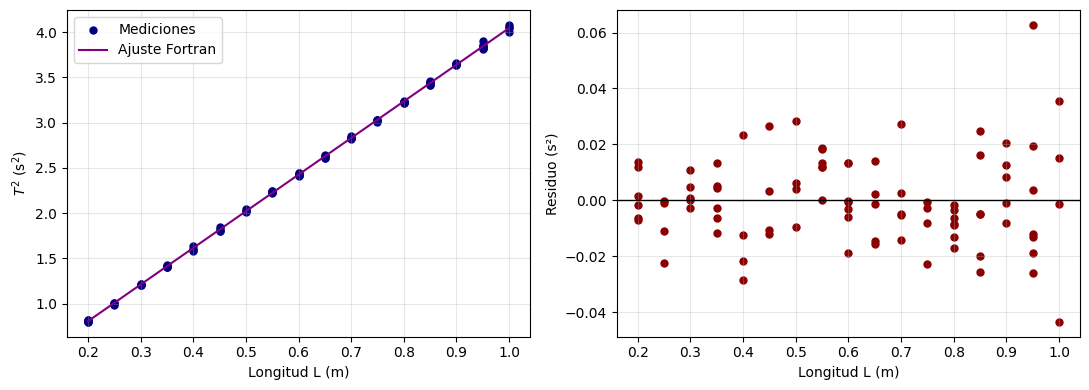

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# Lee las cinco columnas producidas por el script de limpieza
datos = np.loadtxt("pendulo_limpio.dat")
longitud_m = datos[:, 1] / 100.0
numero_oscilaciones = datos[:, 3]
tiempo_total_s = datos[:, 4]

# TODO: construya las variables linealizadas x=L y y=T^2
periodo_s = (tiempo_total_s/numero_oscilaciones)
x = longitud_m
y = periodo_s **2

# Copie los parámetros calculados por su programa Fortran
a = 4.048735
b = -0.002888

# Ordena x para dibujar una línea continua de izquierda a derecha
orden = np.argsort(x)
y_ajustada = a*x + b
residuos = y - y_ajustada

# Primer panel: mediciones y recta. Segundo panel: residuos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.scatter(x, y, s=25, color="navy", label="Mediciones")
ax1.plot(x[orden], y_ajustada[orden], color="purple", label="Ajuste Fortran")
ax1.set_xlabel("Longitud L (m)")
ax1.set_ylabel(r"$T^2$ (s$^2$)")
ax1.grid(alpha=0.3)
ax1.legend()

ax2.axhline(0.0, color="black", linewidth=1)
ax2.scatter(x, residuos, s=25, color="darkred")
ax2.set_xlabel("Longitud L (m)")
ax2.set_ylabel("Residuo (s²)")
ax2.grid(alpha=0.3)

plt.tight_layout()
# Guarda la figura que se entregará con el informe
plt.savefig("ajuste_pendulo_y_residuos.png", dpi=200, bbox_inches="tight")
plt.show()

# **PARTE D:**
Calcule el error relativo porcentual mediante

$$\text{error relativo}=\left|\frac{g_{\mathrm{estimada}}-9.81}{9.81}\right|\times100\%. $$

Con el fin de incluirlo en el reporte y realizar conclusiones.

In [65]:
g_estimada = 9.750804                               #definimos nuestra g estimada del paso B
Erelav = abs((g_estimada - 9.81)/9.81) * 100        #realizamos la formula

print(f"El error relativo porcentual es: {Erelav:.2f}%")      #imprimimos con 2 decimales

El error relativo porcentual es: 0.60%


# **VERIFICACION FINAL PASS/FAIL:**

Para agilizar la revisión, la tarea debe cerrar ejecutando esta celda. La verificación calcula valores de referencia directamente a partir de `pendulo_limpio.dat` y los compara con `resultados_ajuste.dat`. También comprueba que se haya generado la figura.

Un `PASS` indica que el resultado supera esa comprobación automática; no sustituye la revisión de la limpieza, la estructura del programa, las unidades ni la interpretación física.

In [66]:
from pathlib import Path
import numpy as np

# Función auxiliar que imprime un veredicto uniforme para cada prueba
resultados_pruebas = []

def informar(nombre, condicion, detalle=""):
    estado = "PASS" if condicion else "FAIL"
    print(f"{estado:<4}  {nombre}{detalle}")
    resultados_pruebas.append(bool(condicion))
    return bool(condicion)

# Archivos que debe producir el flujo de trabajo completo
archivo_datos = Path("pendulo_limpio.dat")
archivo_resultados = Path("resultados_ajuste.dat")
archivo_figura = Path("ajuste_pendulo_y_residuos.png")

# Primer nivel: comprueba existencia antes de intentar leer
ok_datos = informar("Existe pendulo_limpio.dat", archivo_datos.exists())
ok_resultados = informar("Existe resultados_ajuste.dat", archivo_resultados.exists())
informar("Existe la figura", archivo_figura.exists() and archivo_figura.stat().st_size > 0 if archivo_figura.exists() else False)

# Segundo nivel: valida formatos y compara con un cálculo independiente
if ok_datos and ok_resultados:
    try:
        datos = np.atleast_2d(np.loadtxt(archivo_datos))
        resultados = np.loadtxt(archivo_resultados).reshape(-1)

        estructura_datos = datos.shape[1] == 5 and datos.shape[0] >= 2
        estructura_resultados = resultados.size == 5
        informar("Formato del archivo de datos", estructura_datos, f"  filas={datos.shape[0]}, columnas={datos.shape[1]}")
        informar("Formato del archivo de resultados", estructura_resultados, f"  valores={resultados.size}")

        if estructura_datos and estructura_resultados:
            # Reconstruye x=L y y=T^2 directamente desde los datos limpios
            longitud_m = datos[:, 1] / 100.0
            periodo_s = datos[:, 4] / datos[:, 3]
            x = longitud_m
            y = periodo_s**2
            n_ref = len(x)

            # Calcula los valores de referencia con las fórmulas del método
            sx = np.sum(x)
            sy = np.sum(y)
            sxx = np.sum(x*x)
            sxy = np.sum(x*y)
            den = n_ref*sxx - sx*sx
            a_ref = (n_ref*sxy - sx*sy) / den
            b_ref = (sy - a_ref*sx) / n_ref
            residuos_ref = y - (a_ref*x + b_ref)
            sse_ref = np.sum(residuos_ref**2)
            sst_ref = np.sum((y - np.mean(y))**2)
            r2_ref = 1.0 - sse_ref/sst_ref
            g_ref = 4.0*np.pi**2/a_ref

            # Compara, con tolerancia, cada resultado entregado por Fortran
            n_f, a_f, b_f, r2_f, g_f = resultados
            informar("Número de datos N", int(round(n_f)) == n_ref, f"  obtenido={n_f:g}, esperado={n_ref}")
            informar("Pendiente a", np.isclose(a_f, a_ref, rtol=1e-6, atol=1e-9), f"  obtenida={a_f:.8g}, esperada={a_ref:.8g}")
            informar("Intercepto b", np.isclose(b_f, b_ref, rtol=1e-6, atol=1e-9), f"  obtenido={b_f:.8g}, esperado={b_ref:.8g}")
            informar("Coeficiente R²", np.isclose(r2_f, r2_ref, rtol=1e-6, atol=1e-9), f"  obtenido={r2_f:.8g}, esperado={r2_ref:.8g}")
            informar("Gravedad g", np.isclose(g_f, g_ref, rtol=1e-6, atol=1e-9), f"  obtenida={g_f:.8g}, esperada={g_ref:.8g}")
            informar("Valor físico razonable de g", 7.0 < g_f < 12.0, f"  g={g_f:.5f} m/s²")
    except Exception as error:
        informar("No fue posible completar la verificación", False, f": {error}")

# Resumen que debe copiarse en el informe de una página
n_pass = sum(resultados_pruebas)
n_total = len(resultados_pruebas)
print(f"\nRESUMEN PASS/FAIL: {n_pass} de {n_total} pruebas pasaron.")

PASS  Existe pendulo_limpio.dat
PASS  Existe resultados_ajuste.dat
PASS  Existe la figura
PASS  Formato del archivo de datos  filas=89, columnas=5
PASS  Formato del archivo de resultados  valores=5
PASS  Número de datos N  obtenido=89, esperado=89
PASS  Pendiente a  obtenida=4.0487347, esperada=4.0487347
PASS  Intercepto b  obtenido=-0.0028878571, esperado=-0.0028878571
PASS  Coeficiente R²  obtenido=0.99974782, esperado=0.99974782
PASS  Gravedad g  obtenida=9.7508043, esperada=9.7508038
PASS  Valor físico razonable de g  g=9.75080 m/s²

RESUMEN PASS/FAIL: 11 de 11 pruebas pasaron.
